In [1]:
from pathlib import Path


def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise SystemExit(
        "ไม่พบโฟลเดอร์ datasets/ — เปิด JupyterLab จาก repo root (uv run "
        "jupyter lab)"
    )


DATA = data_dir()


**Dataset ที่ใช้ในโมดูลนี้ (โปรดอ่านก่อนใช้งาน):**

- *SECOM* — McCann, M. & Johnston, A. (2008). *SECOM* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C54305 (CC BY 4.0)
- *Combined Cycle Power Plant* — Tüfekci, P. & Kaya, H. (2014). *Combined Cycle Power Plant* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5002N (CC BY 4.0)

ไฟล์: `datasets/secom.zip`, `datasets/ccpp_power_plant.csv`

# Solution — Module 5: Evaluation

เฉลยของ `exercise.ipynb` — แต่ละข้อมี code เต็ม + สรุปสั้น ๆ ท้ายข้อ ทุกอย่าง deterministic ด้วย `random_state=42`

ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)

---- SECOM (classification part) ----

---- CCPP (regression part) ----


In [2]:
from sklearn.preprocessing import StandardScaler  # noqa: E402
from sklearn.pipeline import make_pipeline  # noqa: E402
from sklearn.model_selection import (  # noqa: E402
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.metrics import (  # noqa: E402
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.linear_model import (  # noqa: E402
    LinearRegression,
    LogisticRegression,
)
from sklearn.impute import SimpleImputer  # noqa: E402
from sklearn.ensemble import (  # noqa: E402
    RandomForestClassifier,
    RandomForestRegressor,
)
import polars as pl  # noqa: E402
import numpy as np  # noqa: E402
import io  # noqa: E402
import zipfile  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402

plt.rcParams["font.family"] = [
    "DejaVu Sans",
    "Noto Sans Thai",
    "Leelawadee UI",
    "Tahoma",
    "Thonburi",
]

with zipfile.ZipFile(DATA / "secom.zip") as z:
    feats = pl.read_csv(
        io.BytesIO(z.read("secom.data")),
        separator=" ",
        has_header=False,
        new_columns=[f"feature_{i}" for i in range(1, 591)],
        schema_overrides={f"feature_{i}": pl.Float64 for i in range(1, 591)},
    )
    lab = pl.read_csv(
        io.BytesIO(z.read("secom_labels.data")),
        separator=" ",
        quote_char='"',
        has_header=False,
        new_columns=["label", "timestamp"],
        schema_overrides={"label": pl.Int64, "timestamp": pl.Utf8},
    )
y_secom = (lab["label"] == 1).to_numpy().astype(int)  # 1 = FAIL
X_secom = feats.to_numpy()
cut = int(len(y_secom) * 0.8)
Xtr_t, Xte_t = X_secom[:cut], X_secom[cut:]  # time-based split
ytr_t, yte_t = y_secom[:cut], y_secom[cut:]

ccpp = pl.read_csv(DATA / "ccpp_power_plant.csv")
Xc = ccpp.select("AT", "V", "AP", "RH").to_numpy()
yc = ccpp["PE"].to_numpy()
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, random_state=42
)

print(f"SECOM {X_secom.shape}, fails {y_secom.sum()} | CCPP {ccpp.shape}")

SECOM (1567, 590), fails 104 | CCPP (9568, 5)


## ข้อ A1 — `evaluate()` : ไม้บรรทัดมาตรฐานของ QC lab

In [3]:
def evaluate(model, X_train, y_train, X_test, y_test):
    """Fit (impute -> scale -> model) and return 6 standard metrics on the "
    "test set."""
    pipe = make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(), model
    )
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
    }


metrics_log = evaluate(
    LogisticRegression(max_iter=2000, random_state=42),
    Xtr_t,
    ytr_t,
    Xte_t,
    yte_t,
)
for k, v in metrics_log.items():
    print(f"{k:>10s} = {v:.3f}")

lazy = np.zeros_like(yte_t)
print(
    f"\nโมเดลเกเร (เดา PASS ทุกชิ้น): accuracy = {
        accuracy_score(yte_t, lazy):.3f}, recall = 0.000"
)


  accuracy = 0.930
 precision = 0.222
    recall = 0.118
        f1 = 0.154
   roc_auc = 0.757
    pr_auc = 0.157

โมเดลเกเร (เดา PASS ทุกชิ้น): accuracy = 0.946, recall = 0.000


**สรุป:** accuracy 0.930 ดูดี แต่ **โมเดลเกเรที่เดา PASS ทุกชิ้นก็ได้ 0.946** — สูงกว่าโมเดลจริงของเราซะอีก ที่บอกคุณภาพของ gauge ได้ตรงคือ **recall (0.118 — จับของเสียได้แค่ 2/17)** และ pr_auc (0.157) สำหรับ gauge QC ที่ false accept แพงกว่า ทุก metric ต้องถูกอ่านเทียบกับ baseline ของข้อมูลไม่สมดุล ไม่ใช่เทียบกับ 1.0

## ข้อ A2 — Logistic vs RandomForest ด้วย stratified 5-fold CV

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
candidates = {
    "Logistic": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(max_iter=2000, random_state=42),
    ),
    "RandomForest": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    ),
}
for name, pipe in candidates.items():
    res = cross_validate(
        pipe, X_secom, y_secom, cv=cv, scoring=["roc_auc", "average_precision"]
    )
    for s in ["roc_auc", "average_precision"]:
        v = res[f"test_{s}"]
        print(f"{name:12s} {s:<18s} {v.mean():.3f} ± {v.std():.3f}")


Logistic     roc_auc            0.660 ± 0.023
Logistic     average_precision  0.148 ± 0.028


RandomForest roc_auc            0.722 ± 0.065
RandomForest average_precision  0.178 ± 0.039


**สรุป:** Logistic ~0.66 / RF ~0.72 (ROC-AUC) และ PR-AUC 0.148 vs 0.178 — RF ดีกว่าเล็กน้อย แต่ spread ของ RF เอง (ROC-AUC ±0.065) **ใหญ่พอ ๆ กับความต่างที่เห็น (0.06)** จึงเป็นการตัดสินที่ยังไม่แน่นพอ ข้อสรุปที่ปลอดภัยคือ "RF ดูดีกว่าแต่ความเชื่อมั่นต่ำ เพราะ metric แกว่งระหว่าง folds มาก" — นี่คือการอ่าน CV แบบอ่าน repeatability: ความต่างที่ใกล้เคียงความไม่แน่นอนของการวัด ไม่ใช่การค้นพบที่มั่นคง สังเกตด้วยว่าทั้งสองได้ ROC-AUC ที่น่าประทับใจกว่า PR-AUC มาก — อีกครั้งที่ PR-AUC เป็นไม้บรรทัดที่ซื่อสัตย์กว่า

## ข้อ A3 — เลือก threshold จากต้นทุน: false accept แพง 50 เท่า

false accept (FN) costs 50, false reject (FP) costs 1


best threshold = 0.25 at cost = 717
(default threshold 0.5 costs 757)


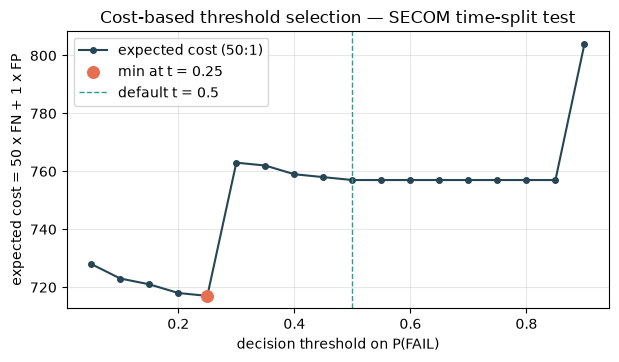

In [5]:
clf = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42),
).fit(Xtr_t, ytr_t)
y_proba = clf.predict_proba(Xte_t)[:, 1]

thresholds = np.round(np.arange(0.05, 0.91, 0.05), 2)
costs = []
for t in thresholds:
    pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yte_t, pred_t).ravel()
    costs.append(50 * fn + 1 * fp)

best_t = thresholds[int(np.argmin(costs))]
print(f"best threshold = {best_t:.2f} at cost = {min(costs):.0f}")
print(
    f"(default threshold 0.5 costs "
    f"{costs[int(np.where(thresholds == 0.5)[0][0])]:.0f})"
)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(
    thresholds,
    costs,
    color="#264653",
    marker="o",
    ms=4,
    label="expected cost (50:1)",
)
ax.scatter(
    [best_t],
    [min(costs)],
    s=70,
    color="#e76f51",
    zorder=3,
    label=f"min at t = {best_t:.2f}",
)
ax.axvline(
    0.5, color="#2a9d8f", linestyle="--", linewidth=1, label="default t = 0.5"
)
ax.set_xlabel("decision threshold on P(FAIL)")
ax.set_ylabel("expected cost = 50 x FN + 1 x FP")
ax.set_title("Cost-based threshold selection — SECOM time-split test")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**สรุป:** threshold ที่ต้นทุนต่ำสุดคือ **0.25 (cost 717)** ต่ำกว่า default 0.5 (cost 757) — เมื่อ FN (false accept) แพง 50 เท่า โมเดลควร "ระแวง FAIL" มากขึ้น จึงต้องเลื่อน threshold **ลง** เพื่อซื้อ recall ด้วย false reject ที่เสียเพิ่มขึ้น สังเกตว่า cost ค่อนข้างแบนในช่วง threshold ต่ำ (0.05–0.25 ให้ cost 717–728): เมื่อของเสียใน test มีแค่ 17 ชิ้น การย้าย threshold มักไม่เปลี่ยน FN/FP จนถึงขั้นบันไดถัดไป (ความละเอียดจำกัดโดยขนาดชุดทดสอบ — เหมือนขีดไม้บรรทัดที่ห่างกัน)

## ข้อ B1 — Regression metrics สองโมเดลบน CCPP

In [6]:
reg_candidates = {
    "Linear": make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(), LinearRegression()
    ),
    "RandomForest": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    ),
}
reg_results = {}
for name, pipe in reg_candidates.items():
    pipe.fit(Xc_tr, yc_tr)
    pred = pipe.predict(Xc_te)
    reg_results[name] = {
        "R2": r2_score(yc_te, pred),
        "RMSE": float(np.sqrt(mean_squared_error(yc_te, pred))),
        "MAE": mean_absolute_error(yc_te, pred),
    }
    r = reg_results[name]
    print(
        f"{name:12s} R2={r['R2']:.4f}  RMSE={r['RMSE']:.2f} MW  MAE={
            r['MAE']:.2f} MW"
    )


Linear       R2=0.9301  RMSE=4.50 MW  MAE=3.60 MW


RandomForest R2=0.9641  RMSE=3.23 MW  MAE=2.31 MW


**สรุป:** RandomForest ชนะชัดเจน (R² 0.964, RMSE 3.23 MW, MAE 2.31 MW) กว่า Linear (~0.930, 4.50 MW, 3.60 MW) เพราะความสัมพันธ์ใน CCPP มีความโค้งจริง สำหรับเล่าเรื่องเมโทรโลยี metric ที่เหมาะที่สุดคือ **RMSE (หรือ MAE) ในหน่วย MW** เพราะมันคือความคลาดเคลื่อนที่ **อ่านเป็นหน่วยจริงของการวัด** ได้ ("ทำนายได้ภายใน ~3.2 MW") — R² เป็นค่า dimensionless ใช้เทียบโมเดลได้ แต่ผู้ใช้เครื่องจักรแปลงเป็น "ผิดพลาดกี่เมกะวัตต์" ไม่ได้ ส่วน RMSE โดน error ใหญ่หนักกว่า MAE (3.23 vs 2.31 บอกว่ามี error หางยาว) จึงระบุด้วยว่าเรากลัว outlier มากแค่ไหน

## ข้อ B2 — Residual plot + relative error ของโมเดลที่ชนะ

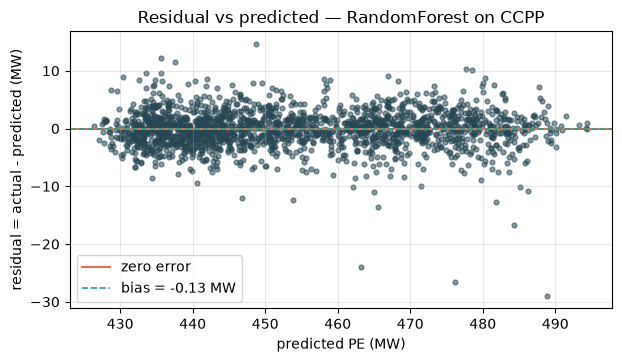

MAPE-style relative error = 0.51%
bias (mean residual) = -0.126 MW | spread (std residual) = 3.23 MW


In [7]:
best_reg = reg_candidates["RandomForest"]
pred_best = best_reg.predict(Xc_te)
resid = yc_te - pred_best

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.scatter(pred_best, resid, s=12, color="#264653", alpha=0.55)
ax.axhline(0, color="#e76f51", linewidth=1.5, label="zero error")
ax.axhline(
    resid.mean(),
    color="#2a9d8f",
    linestyle="--",
    linewidth=1.2,
    label=f"bias = {resid.mean():+.2f} MW",
)
ax.set_xlabel("predicted PE (MW)")
ax.set_ylabel("residual = actual - predicted (MW)")
ax.set_title("Residual vs predicted — RandomForest on CCPP")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

mape = float(np.mean(np.abs(resid / yc_te)) * 100)
print(f"MAPE-style relative error = {mape:.2f}%")
print(
    f"bias (mean residual) = {resid.mean():+.3f} MW | spread (std residual) = {
        resid.std():.2f} MW"
)


**สรุป:** residual กระจายรอบศูนย์โดยไม่มีแนวโน้มเอียงชัดเจน (bias เพียง −0.13 MW เทียบกับ spread 3.23 MW) → ความคลาดเคลื่อนของโมเดลเป็น **spread** ล้วน ๆ ไม่ใช่ bias ที่แก้ได้ด้วยการปรับ offset relative error ราว **0.5%** ของค่าจริง — ตัวเลขที่สื่อสารกับผู้ใช้งานได้ดีกว่า RMSE ตรง ๆ เพราะเทียบข้ามช่วงกำลังไฟฟ้าได้ (ไม่ติดหน่วย absolute) พูดได้ว่า "โมเดลทำนายคลาดเคลื่อนราว 0.5% ของค่ากำลังไฟฟ้าจริง"

## ข้อ B3 — โจทย์คิด

**คำตอบข้อ B3:**

1. ควรตอบทีมขายว่า accuracy 93% มาจากการ "ทาย PASS ทุกชิ้น" ได้เกือบเท่ากัน (94.6%) — ในข้อมูลที่ของเสียมีแค่ 6.6% accuracy ไม่ได้วัดความสามารถของ gauge เลย แทนที่ด้วยชุดรายงาน: **recall (จับของเสียได้กี่ %)**, **precision (ตัดออกแล้วเป็นของเสียจริงกี่ %)**, **PR-AUC (คะแนนรวมที่เส้นฐานคืออัตราของเสีย)** และ **confusion matrix พร้อม threshold ที่ใช้** — พร้อมอธิบายต้นทุน false accept กับ false reject ที่ต่างกัน
2. รายงาน **ทั้งสอง split** พร้อมกำกับชัดว่า split แบบใด (และ seed) — ไม่เลือกเสนอเฉพาะ random split เพราะมันเลียนแบบการ deploy ผิด; การใช้งานจริงคือการทำนายล็อตอนาคต ดังนั้น time split คือตัวเลขที่ต้องยึดเป็นหลัก เหมือนใบสอบเทียบที่ต้องระบุ "ช่วงการใช้งานที่ผลนี้ใช้ได้" — การเลือกเสนอเฉพาะตัวเลขที่ดีที่สุดโดยไม่บอกเงื่อนไข คือการรายงานที่ไม่ซื่อสัตย์ทางเมโทรโลยี